In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

sklearn.set_config(display='text')


## Weight

In [6]:
data = np.load('C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\data\\weight_dynamic\\hebb-full_model0-weight-num0.npz')

In [7]:
layer0 = data['arr_0'].reshape(data['arr_0'].shape[0], -1)
layer1 = data['arr_1'].reshape(data['arr_1'].shape[0], -1)
layer2 = data['arr_2'].reshape(data['arr_2'].shape[0], -1)
print(f"layer0.shape: {layer0.shape}, layer1.shape: {layer1.shape}, layer2.shape: {layer2.shape}")

flatten_weight = np.concatenate([layer0, layer1, layer2],axis=1)
print(f"flatten_weight.shape: {flatten_weight.shape}")

layer0.shape: (1000, 8192), layer1.shape: (1000, 8192), layer2.shape: (1000, 1216)
flatten_weight.shape: (1000, 17600)


## Data

In [4]:
data = np.load('C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\data\\weight_dynamic\\hebb-full_model0-buffer.npy', allow_pickle=True)
print(f"ALL keys: {list(data.item().keys())}")

ALL keys: ['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled']


In [ ]:
dof_pos_scale = data.item()['state'][:,0,:19]
dof_vel_scale = data.item()['state'][:,0,19:38]
action        = data.item()['state'][:,0,38:57]
imu           = data.item()['state'][:,0,57:60]
fc            = data.item()['state'][:,0,60:64]

print(f"dof_pos_scale.shape: {dof_pos_scale.shape}, dof_vel_scale.shape: {dof_vel_scale.shape}, imion.shape: {imion.shape}, imu.shape: {imu.shape}, fc.shape: {fc.shape}")

dof_pos_scale.shape: (1000, 19), dof_vel_scale.shape: (1000, 19), action.shape: (1000, 19), imu.shape: (1000, 3), fc.shape: (1000, 4)


## Mutual information

In [28]:
layer0_num_weight = layer0.shape[1]
layer1_num_weight = layer1.shape[1]
layer2_num_weight = layer2.shape[1]

### Pos

In [ ]:
# # ------ Layer 0 ------ 
mi_pos_layer0 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(dof_pos_scale, layer0[:,i]) # dim (number of hidden layer0 neuron)
    mi_pos_layer0.append(_mi)

mi_pos_layer0 = np.array(mi_pos_layer0)
np.save("pos-layer0.npy",mi_pos_layer0)


# # ------ Layer 1 ------ 
# mi_pos_layer1 = []

# for i in range(layer1_num_weight):
#     _mi = mutual_info_regression(dof_pos_scale, layer1[:,i])
#     mi_pos_layer1.append(_mi)

# mi_pos_layer1 = np.array(mi_pos_layer1)
# np.save("pos-layer1.npy",mi_pos_layer1)


# ------ Layer 2 ------ 
mi_pos_layer2 = []

for i in range(layer2_num_weight):
    _mi = mutual_info_regression(dof_pos_scale, layer2[:,i])
    mi_pos_layer2.append(_mi)

mi_pos_layer2 = np.array(mi_pos_layer2)
np.save("pos-layer2.npy",mi_pos_layer2)

### Vel


In [32]:
# ------ Layer 0 ------ 
mi_vel_layer0 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(dof_vel_scale, layer0[:,i])
    mi_vel_layer0.append(_mi)

mi_vel_layer0 = np.array(mi_vel_layer0)
np.save("vel-layer0.npy",mi_vel_layer0)


# ------ Layer 1 ------ 
mi_vel_layer1 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(dof_vel_scale, layer1[:,i])
    mi_vel_layer1.append(_mi)

mi_vel_layer1 = np.array(mi_vel_layer1)
np.save("vel-layer1.npy",mi_vel_layer1)

# ------ Layer 1 ------ 
mi_vel_layer2 = []

for i in range(layer2_num_weight):
    _mi = mutual_info_regression(dof_vel_scale, layer2[:,i])
    mi_vel_layer2.append(_mi)

mi_vel_layer2 = np.array(mi_vel_layer2)
np.save("vel-layer2.npy",mi_vel_layer2)


### Act

In [33]:
# ------ Layer 0 ------ 
layer0_num_weight = layer0.shape[1]
mi_act_layer0 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(dof_vel_scale, layer0[:,i])
    mi_act_layer0.append(_mi)

mi_act_layer0 = np.array(mi_act_layer0)
np.save("act-layer0.npy",mi_act_layer0)


# ------ Layer 1 ------ 
layer1_num_weight = layer0.shape[1]
mi_act_layer1 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(action, layer1[:,i])
    mi_act_layer1.append(_mi)

mi_act_layer1 = np.array(mi_act_layer1)
np.save("act-layer1.npy",mi_act_layer1)

# ------ Layer 1 ------ 
layer2_num_weight = layer2.shape[1]
mi_act_layer2 = []

for i in range(layer2_num_weight):
    _mi = mutual_info_regression(action, layer2[:,i])
    mi_act_layer2.append(_mi)

mi_act_layer2 = np.array(mi_act_layer2)
np.save("act-layer2.npy",mi_act_layer2)


### IMU

In [34]:
# ------ Layer 0 ------ 
mi_imu_layer0 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(imu, layer0[:,i])
    mi_imu_layer0.append(_mi)

mi_imu_layer0 = np.array(mi_imu_layer0)
np.save("imu-layer0.npy",mi_imu_layer0)


# ------ Layer 1 ------ 
mi_imu_layer1 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(imu, layer1[:,i])
    mi_imu_layer1.append(_mi)

mi_imu_layer1 = np.array(mi_imu_layer1)
np.save("imu-layer1.npy",mi_imu_layer1)

# ------ Layer 1 ------ 
mi_imu_layer2 = []

for i in range(layer2_num_weight):
    _mi = mutual_info_regression(imu, layer2[:,i])
    mi_imu_layer2.append(_mi)

mi_imu_layer2 = np.array(mi_imu_layer2)
np.save("imu-layer2.npy",mi_imu_layer2)


### FC

In [35]:
# ------ Layer 0 ------ 
mi_fc_layer0 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(fc, layer0[:,i])
    mi_fc_layer0.append(_mi)

mi_fc_layer0 = np.array(mi_fc_layer0)
np.save("fc-layer0.npy",mi_fc_layer0)


# ------ Layer 1 ------ 
mi_fc_layer1 = []

for i in range(layer0_num_weight):
    _mi = mutual_info_regression(fc, layer1[:,i])
    mi_fc_layer1.append(_mi)

mi_fc_layer1 = np.array(mi_fc_layer1)
np.save("fc-layer1.npy",mi_fc_layer1)

# ------ Layer 1 ------ 
mi_fc_layer2 = []

for i in range(layer2_num_weight):
    _mi = mutual_info_regression(fc, layer2[:,i])
    mi_fc_layer2.append(_mi)

mi_fc_layer2 = np.array(mi_fc_layer2)
np.save("fc-layer2.npy",mi_fc_layer2)


## Plot

### Layer 0

In [52]:
MI_PATH  = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\weight_analysis\mutual_information"
SENSOR = ["pos" , "vel", "act", "imu", "fc"]
LAYER = 0

pos = np.load(os.path.join(MI_PATH, f"pos-layer{LAYER}.npy"))
vel = np.load(os.path.join(MI_PATH, f"vel-layer{LAYER}.npy"))
act = np.load(os.path.join(MI_PATH, f"act-layer{LAYER}.npy"))
imu = np.load(os.path.join(MI_PATH, f"imu-layer{LAYER}.npy"))
fc = np.load(os.path.join(MI_PATH, f"fc-layer{LAYER}.npy"))

mi_sensor = np.stack([pos.mean(), vel.mean(), act.mean(), imu.mean(), fc.mean()])

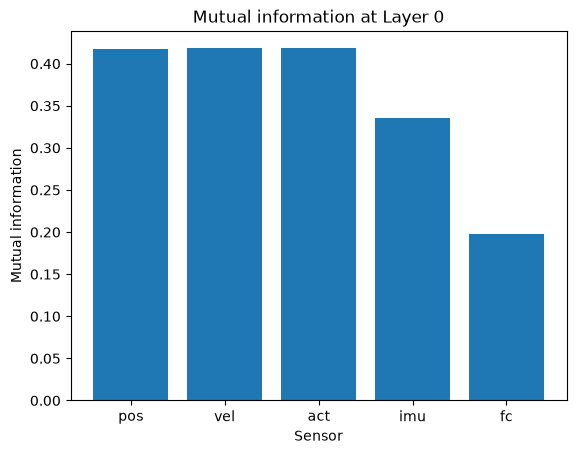

In [53]:
plt.bar(SENSOR, mi_sensor)
plt.title(f'Mutual information at Layer {LAYER}')
plt.xlabel('Sensor')
plt.ylabel('Mutual information')
plt.show()

### Layer 1

In [56]:
MI_PATH  = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\weight_analysis\mutual_information"
SENSOR = ["pos" , "vel", "act", "imu", "fc"]
LAYER = 1

pos = np.load(os.path.join(MI_PATH, f"pos-layer{LAYER}.npy"))
vel = np.load(os.path.join(MI_PATH, f"vel-layer{LAYER}.npy"))
act = np.load(os.path.join(MI_PATH, f"act-layer{LAYER}.npy"))
imu = np.load(os.path.join(MI_PATH, f"imu-layer{LAYER}.npy"))
fc = np.load(os.path.join(MI_PATH, f"fc-layer{LAYER}.npy"))

mi_sensor = np.stack([pos.mean(), vel.mean(), act.mean(), imu.mean(), fc.mean()])

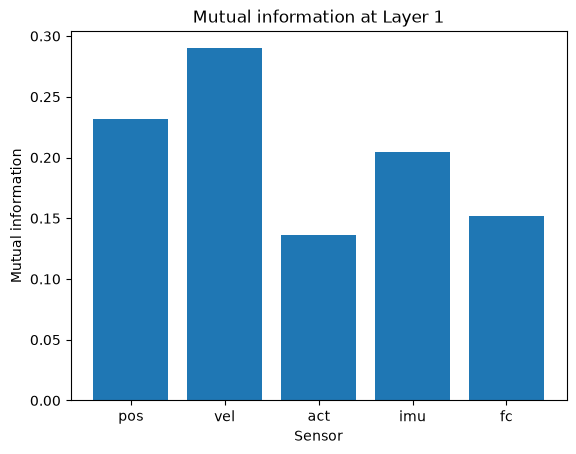

In [57]:
plt.bar(SENSOR, mi_sensor)
plt.title(f'Mutual information at Layer {LAYER}')
plt.xlabel('Sensor')
plt.ylabel('Mutual information')
plt.show()

### Layer 2

In [58]:
MI_PATH  = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\weight_analysis\mutual_information"
SENSOR = ["pos" , "vel", "act", "imu", "fc"]
LAYER = 2

pos = np.load(os.path.join(MI_PATH, f"pos-layer{LAYER}.npy"))
vel = np.load(os.path.join(MI_PATH, f"vel-layer{LAYER}.npy"))
act = np.load(os.path.join(MI_PATH, f"act-layer{LAYER}.npy"))
imu = np.load(os.path.join(MI_PATH, f"imu-layer{LAYER}.npy"))
fc = np.load(os.path.join(MI_PATH, f"fc-layer{LAYER}.npy"))

mi_sensor = np.stack([pos.mean(), vel.mean(), act.mean(), imu.mean(), fc.mean()])

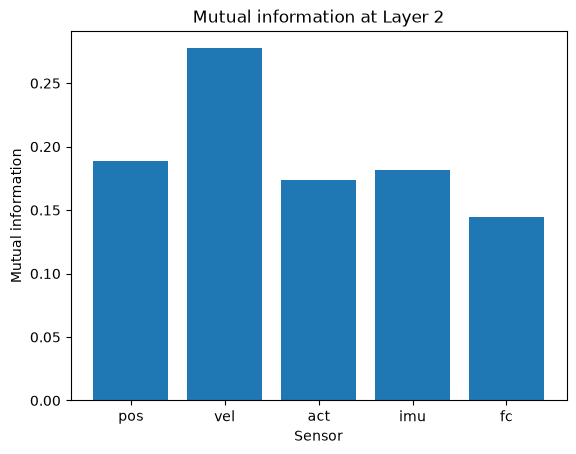

In [59]:
plt.bar(SENSOR, mi_sensor)
plt.title(f'Mutual information at Layer {LAYER}')
plt.xlabel('Sensor')
plt.ylabel('Mutual information')
plt.show()